In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Open the file in a dataframe
# Note: The file uses a semicolon (;) as a separator and comma (,) as a decimal point
df = pd.read_csv('data/electricityloaddiagrams20112014/LD2011_2014.txt', sep=';', decimal=',', parse_dates=[0], index_col=0, low_memory=False)

# Display the first few rows and their data types
display(df.head())
print(df.dtypes)

In [ ]:
# Percentage of zeros for each column
zero_counts = (df == 0).sum()
zero_percentages = (df == 0).mean() * 100

# Summary of 0 distributions
print('Summary of Zeros % per column:')
display(zero_percentages.describe())

In [7]:
# Percentage of zeros for each column
zero_counts = (df == 0).sum()
zero_percentages = (df == 0).mean() * 100

# Summary of 0 distributions
print('Summary of Zeros % per column:')
zero_percentages.describe()

Summary of Zeros % per column:


count    370.000000
mean      20.151071
std       22.214166
min        0.000000
25%        0.008734
50%       24.991444
75%       25.006595
max       88.637919
dtype: float64


Distribution of First Non-Zero Timestamps (Year-Month):


2011-01    158
2011-02      1
2011-04      1
2012-01    161
2012-03      2
2012-06      1
2012-07      4
2012-08      2
2012-10      1
2012-11      2
2013-01      4
2013-02      1
2013-05      1
2013-06      3
2013-08      2
2013-09      3
2013-10      1
2013-11      1
2013-12      2
2014-01     12
2014-02      4
2014-03      2
2014-07      1
Freq: M, Name: count, dtype: int64

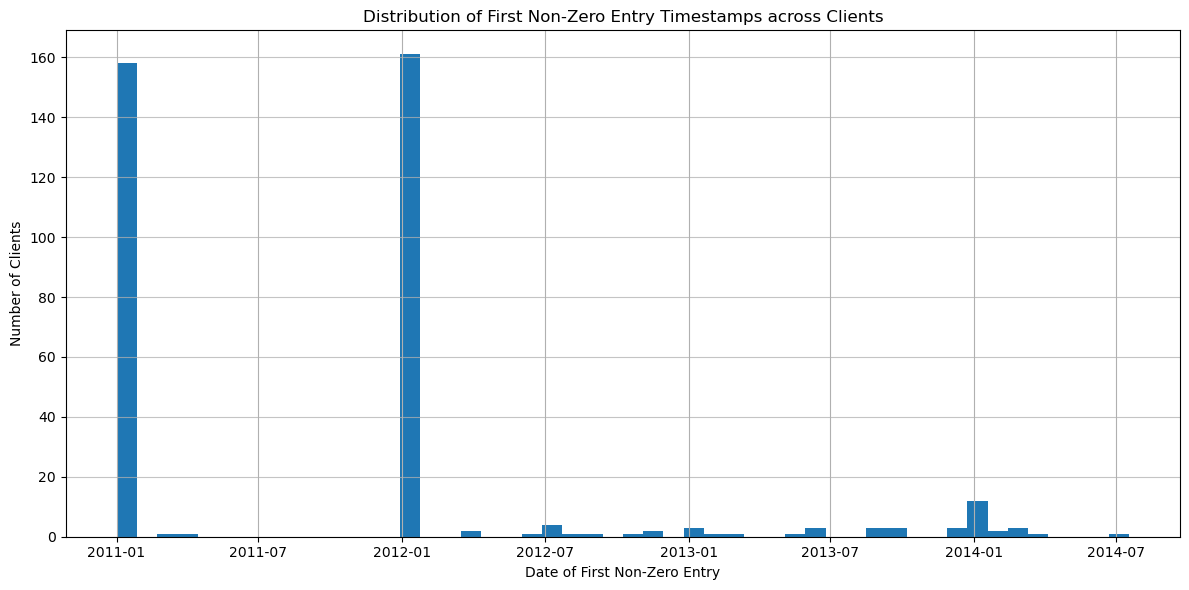

In [8]:
# Replace 0s with NaN to use first_valid_index
df_replaced = df.replace(0, pd.NA)

first_nonzero_timestamps = {}
for col in df.columns:
    first_idx = df_replaced[col].first_valid_index()
    first_nonzero_timestamps[col] = first_idx

first_nonzero_series = pd.Series(first_nonzero_timestamps)

# Summary of first non-zero timestamps
print('\nDistribution of First Non-Zero Timestamps (Year-Month):')
display(first_nonzero_series.dt.to_period('M').value_counts().sort_index())

# Plotting the distribution of first non-zero timestamps
plt.figure(figsize=(12, 6))
first_nonzero_series.hist(bins=50)
plt.title('Distribution of First Non-Zero Entry Timestamps across Clients')
plt.xlabel('Date of First Non-Zero Entry')
plt.ylabel('Number of Clients')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()